# 16 -- Stage 7d shadow-masking + per-image attribution

Refinement of [notebook 15](15_stage7d_pooled.ipynb), adding two pieces:

1. **Shadow-fraction sensitivity sweep**: filter tiles by Stage 4b
   `shadow_fraction` at thresholds {None (baseline), 0.20, 0.10, 0.05} and
   compare pooled effect sizes. Addresses the §5.3 shadow caveat: boulder
   shadows lower single-band I/F in rich tiles, inflating the raw dust
   attribution and shrinking the apparent composition residual.
2. **Per-image attribution table**: the PLAN_Compositional.md §6 deliverable.
   For each eligible ObsId, classify into {composition_residual,
   dust_attributable, no_signal, inconclusive} based on per-image raw vs
   partial-dust effect sizes in the band-ratio features (IR/BG, IR/RED).

**Inputs** (all gitignored, all generated by
[`scripts/run_stage7d_pooled.py`](../scripts/run_stage7d_pooled.py)):

- `dataset_v2/stage7d_pooled.parquet`                -- baseline (no shadow filter)
- `dataset_v2/stage7d_pooled_shadow_0.20.parquet`    -- T=0.20
- `dataset_v2/stage7d_pooled_shadow_0.10.parquet`    -- T=0.10 (headline)
- `dataset_v2/stage7d_pooled_shadow_0.05.parquet`    -- T=0.05 (strict)
- `dataset_v2/stage7d_per_image_attribution.parquet` -- baseline attribution
- `dataset_v2/stage7d_attribution_shadow_0.10.parquet` -- T=0.10 attribution

Regenerate any of these via:

```powershell
& "C:/Users/brian/anaconda3/Scripts/conda.exe" run --no-capture-output -n geospatial `
    python -u scripts/run_stage7d_pooled.py --shadow-threshold 0.10 `
    --out dataset_v2/stage7d_pooled_shadow_0.10.parquet `
    --attribution-out dataset_v2/stage7d_attribution_shadow_0.10.parquet
```


## 1. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))
from src import stage7d_pooled as s7d  # noqa: E402

DATASET = ROOT / "dataset_v2"
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

THRESHOLDS = [("baseline", None), ("0.20", 0.20), ("0.10", 0.10), ("0.05", 0.05)]
FEATURES = list(s7d.COLOUR_FEATURES)
RATIO_FEATURES = list(s7d.ATTRIBUTION_FEATURES)

def _pooled_path(label):
    if label == "baseline":
        return DATASET / "stage7d_pooled.parquet"
    return DATASET / f"stage7d_pooled_shadow_{label}.parquet"

def _attribution_path(label):
    if label == "baseline":
        return DATASET / "stage7d_per_image_attribution.parquet"
    return DATASET / f"stage7d_attribution_shadow_{label}.parquet"

pooled = {label: pd.read_parquet(_pooled_path(label)) for label, _ in THRESHOLDS}
attribution = {label: pd.read_parquet(_attribution_path(label)) for label, _ in THRESHOLDS}
for label, _ in THRESHOLDS:
    p4 = (pooled[label]
        .query("level == 'pooled' and partition_rule == 'P4_area' "
               "and test_type == 'mann_whitney_standardised'"))
    print(f"{label:>10s}: rows={len(pooled[label]):4d}, "
          f"P4 n_images={int(p4['n_images_pooled'].iloc[0]) if len(p4) else 'NA'}, "
          f"P4 n_rich+n_poor={int(p4['n_rich'].sum() + p4['n_poor'].sum())//6 if len(p4) else 'NA'}")


  baseline: rows= 954, P4 n_images=30, P4 n_rich+n_poor=8355
      0.20: rows= 921, P4 n_images=27, P4 n_rich+n_poor=5907
      0.10: rows= 899, P4 n_images=26, P4 n_rich+n_poor=4450
      0.05: rows= 855, P4 n_images=24, P4 n_rich+n_poor=3644


## 2. Threshold sweep -- pooled standardised effect sizes (P4_area)

Effect-size magnitudes per feature x shadow threshold. **Key claim**:

- Raw single-band effects SHRINK as we tighten the shadow filter -- consistent
  with shadow being a major driver of the "rich is darker" raw signal.
- `dust_index` raw effect collapses to non-significance at T=0.10 -- the
  "rich is less dusty" raw signal was largely shadow-driven, not dust-driven.
- Partial-dust single-band effects GROW under shadow filtering -- the
  composition residual was being masked by shadow contamination at baseline.


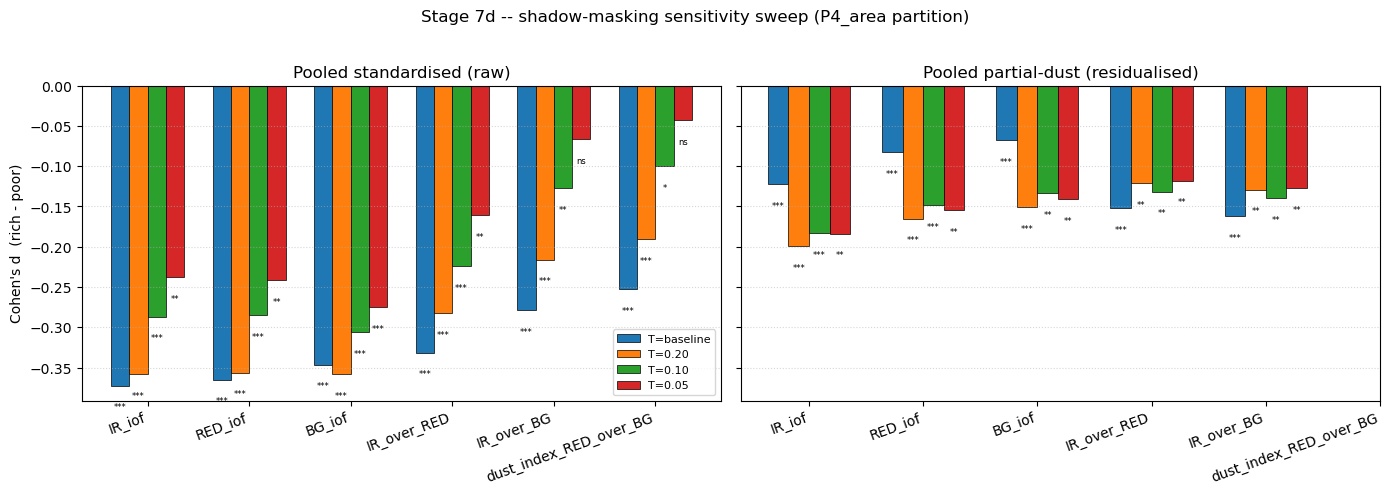

Pivot of effect sizes (rounded):


threshold                                         baseline   0.20   0.10  \
test_type                 feature                                          
mann_whitney_partial_dust BG_iof                    -0.068 -0.151 -0.133   
                          IR_iof                    -0.122 -0.199 -0.183   
                          IR_over_BG                -0.162 -0.129 -0.140   
                          IR_over_RED               -0.152 -0.121 -0.132   
                          RED_iof                   -0.082 -0.165 -0.148   
mann_whitney_standardised BG_iof                    -0.346 -0.358 -0.306   
                          IR_iof                    -0.372 -0.358 -0.287   
                          IR_over_BG                -0.279 -0.216 -0.127   
                          IR_over_RED               -0.331 -0.283 -0.224   
                          RED_iof                   -0.365 -0.356 -0.285   
                          dust_index_RED_over_BG    -0.252 -0.191 -0.100   

threshold                                          0.05  
test_type                 feature                        
mann_whitney_partial_dust BG_iof                 -0.141  
                          IR_iof                 -0.184  
                          IR_over_BG             -0.127  
                          IR_over_RED            -0.118  
                          RED_iof                -0.155  
mann_whitney_standardised BG_iof                 -0.275  
                          IR_iof                 -0.238  
                          IR_over_BG             -0.067  
                          IR_over_RED            -0.161  
                          RED_iof                -0.241  
                          dust_index_RED_over_BG -0.043

In [2]:
rows = []
for label, _ in THRESHOLDS:
    for test_type in ["mann_whitney_standardised", "mann_whitney_partial_dust"]:
        sub = pooled[label].query(
            "level == 'pooled' and partition_rule == 'P4_area' "
            "and test_type == @test_type")
        for _, r in sub.iterrows():
            rows.append({
                "threshold": label, "test_type": test_type,
                "feature": r["feature"], "effect_size": r["effect_size"],
                "p_value": r["p_value"], "n_rich": r["n_rich"], "n_poor": r["n_poor"],
            })
sweep = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
for ax, test_type, title in zip(
    axes,
    ["mann_whitney_standardised", "mann_whitney_partial_dust"],
    ["Pooled standardised (raw)", "Pooled partial-dust (residualised)"],
):
    sub = sweep[sweep["test_type"] == test_type]
    width = 0.18
    x = np.arange(len(FEATURES))
    for i, (label, _) in enumerate(THRESHOLDS):
        sub_t = sub[sub["threshold"] == label].set_index("feature").reindex(FEATURES)
        vals = sub_t["effect_size"].to_numpy()
        bars = ax.bar(x + (i - 1.5) * width, vals, width=width, label=f"T={label}",
                      edgecolor="black", linewidth=0.5)
        for xi, v, p in zip(x + (i - 1.5) * width, vals,
                            sub_t["p_value"].to_numpy()):
            sig = "***" if p < 1e-10 else ("**" if p < 1e-3 else ("*" if p < 0.05 else "ns"))
            ax.text(xi, v + (0.005 if v >= 0 else -0.03), sig,
                    fontsize=6, ha="center")
    ax.axhline(0, color="k", linewidth=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(FEATURES, rotation=20, ha="right")
    ax.set_title(title)
    ax.grid(True, axis="y", linestyle=":", alpha=0.5)
axes[0].set_ylabel("Cohen's d  (rich - poor)")
axes[0].legend(loc="lower right", fontsize=8)
fig.suptitle("Stage 7d -- shadow-masking sensitivity sweep (P4_area partition)",
             y=1.02)
fig.tight_layout()
fig.savefig(FIG / "stage7d_shadow_sweep.png", dpi=140, bbox_inches="tight")
plt.show()

print("Pivot of effect sizes (rounded):")
piv = (sweep.assign(effect=sweep["effect_size"].round(3))
       .pivot_table(index=["test_type", "feature"], columns="threshold",
                    values="effect", aggfunc="first")
       .reindex(["baseline", "0.20", "0.10", "0.05"], axis=1))
piv


## 3. Partial-dust comparison -- baseline vs headline (T=0.10)

The simplest "before vs after" cut: pooled standardised partial-dust effects
at baseline vs T=0.10. For single bands the partial-dust effect grows ~50 %
under shadow filtering; for band ratios it shifts modestly.


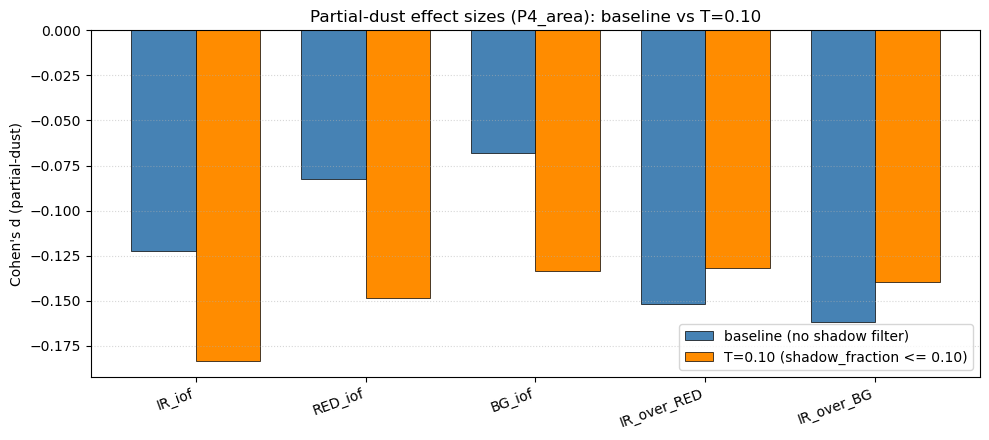

In [3]:
def _partial(label):
    return (pooled[label]
        .query("level == 'pooled' and partition_rule == 'P4_area' "
               "and test_type == 'mann_whitney_partial_dust'")
        .set_index("feature"))

base = _partial("baseline").reindex(FEATURES)
masked = _partial("0.10").reindex(FEATURES)

fig, ax = plt.subplots(figsize=(10, 4.5))
non_dust = [f for f in FEATURES if f != s7d.DUST_COL]
x = np.arange(len(non_dust))
width = 0.38
ax.bar(x - width/2, base.loc[non_dust, "effect_size"].to_numpy(),
       width=width, label="baseline (no shadow filter)",
       color="steelblue", edgecolor="black", linewidth=0.5)
ax.bar(x + width/2, masked.loc[non_dust, "effect_size"].to_numpy(),
       width=width, label="T=0.10 (shadow_fraction <= 0.10)",
       color="darkorange", edgecolor="black", linewidth=0.5)
ax.axhline(0, color="k", linewidth=0.7)
ax.set_xticks(x); ax.set_xticklabels(non_dust, rotation=20, ha="right")
ax.set_ylabel("Cohen's d (partial-dust)")
ax.set_title("Partial-dust effect sizes (P4_area): baseline vs T=0.10")
ax.legend(loc="best")
ax.grid(True, axis="y", linestyle=":", alpha=0.5)
fig.tight_layout()
fig.savefig(FIG / "stage7d_partial_dust_shadow_compare.png", dpi=140,
            bbox_inches="tight")
plt.show()


## 4. Per-image attribution table (PLAN §6 deliverable)

For each eligible ObsId, classify into one of:

- **`composition_residual`** -- raw rich-vs-poor effect present in IR/BG or
  IR/RED (|d| >= 0.20 and p <= 1e-3), AND partial-dust effect also present
  (|d| >= 0.10 and p <= 0.05). Provenance ambiguous (locally-sourced-with-
  maturity vs transported) per PLAN §11.
- **`dust_attributable`** -- raw effect present but partial-dust effect
  disappears (|d| < 0.10 OR p > 0.05). The signal IS the dust loading.
- **`no_signal`** -- no raw effect detected; image contributes no usable
  per-image evidence either way.

The table below is shown for the headline T=0.10 shadow-masked attribution.


In [4]:
attr_headline = attribution["0.10"]
attr_baseline = attribution["baseline"]

def _summary(attr, label):
    rows = []
    for rule in ("P4_area", "P2_count"):
        counts = attr[attr["partition_rule"] == rule]["attribution"].value_counts()
        rows.append({"threshold": label, "partition_rule": rule, **counts.to_dict()})
    return pd.DataFrame(rows).fillna(0)

summary = pd.concat([
    _summary(attr_baseline, "baseline"),
    _summary(attribution["0.20"], "0.20"),
    _summary(attr_headline, "0.10"),
    _summary(attribution["0.05"], "0.05"),
], ignore_index=True)
print("Attribution counts by partition_rule x shadow threshold:")
print(summary.to_string(index=False))

# Headline per-image table (T=0.10, P4_area)
disp = attr_headline.query("partition_rule == 'P4_area'").copy()
disp = disp.sort_values(["attribution", "obs_id"])
disp[["obs_id", "attribution", "n_rich", "n_poor",
      "IR_over_BG_raw_d", "IR_over_BG_raw_p",
      "IR_over_BG_partial_d", "IR_over_BG_partial_p",
      "IR_over_RED_raw_d", "IR_over_RED_raw_p",
      "IR_over_RED_partial_d", "IR_over_RED_partial_p"]]


Attribution counts by partition_rule x shadow threshold:
threshold partition_rule  no_signal  dust_attributable  composition_residual
 baseline        P4_area         15                  8                     7
 baseline       P2_count         16                  8                     9
     0.20        P4_area         14                  8                     5
     0.20       P2_count         19                  8                     6
     0.10        P4_area         16                  5                     5
     0.10       P2_count         19                  8                     5
     0.05        P4_area         15                  6                     3
     0.05       P2_count         19                  6                     5


,obs_id,attribution,n_rich,n_poor,IR_over_BG_raw_d,IR_over_BG_raw_p,IR_over_BG_partial_d,IR_over_BG_partial_p,IR_over_RED_raw_d,IR_over_RED_raw_p,IR_over_RED_partial_d,IR_over_RED_partial_p
0,ESP_017355_2260,composition_residual,128,203,-0.708912,1.839835e-08,-0.513337,5.645773e-09,-0.812973,2.267463e-12,-0.511088,8.544974e-09
1,ESP_045139_2270,composition_residual,96,24,-0.493106,6.288745e-02,-1.371984,4.888914e-08,-1.188569,4.735953e-06,-1.372632,5.072700e-08
7,ESP_046959_2225,composition_residual,61,160,-1.196457,2.125839e-12,-0.319932,1.718238e-02,-1.246751,4.255180e-13,-0.362927,7.694587e-03
17,ESP_066634_2210,composition_residual,76,111,0.631698,3.988027e-05,-0.570645,5.550400e-05,-0.288232,1.039880e-02,-0.575683,4.598197e-05
25,ESP_076723_2265,composition_residual,133,101,1.109223,3.744920e-15,-0.378619,4.668928e-03,0.283489,4.121633e-02,-0.376905,5.334038e-03
6,ESP_046328_2180,dust_attributable,21,107,-0.817203,4.219842e-04,-0.107218,5.410351e-01,-0.794746,5.369805e-04,-0.146257,3.885873e-01
10,ESP_053989_2260,dust_attributable,29,67,-1.113278,1.366598e-04,-0.347851,4.157049e-01,-1.162047,2.518839e-05,-0.356067,3.630084e-01
12,ESP_054134_2265,dust_attributable,60,24,-1.301618,5.371531e-06,0.361580,8.763551e-02,-1.117384,2.749560e-05,0.352102,1.765189e-01
16,ESP_064510_2260,dust_attributable,107,200,0.830646,9.065753e-09,0.128955,4.358498e-01,0.833755,4.800730e-09,0.140564,3.041890e-01
20,ESP_069763_2235,dust_attributable,99,11,-3.730129,2.729824e-07,-0.786112,5.083610e-02,-3.984480,1.514367e-07,-0.818867,5.202859e-02


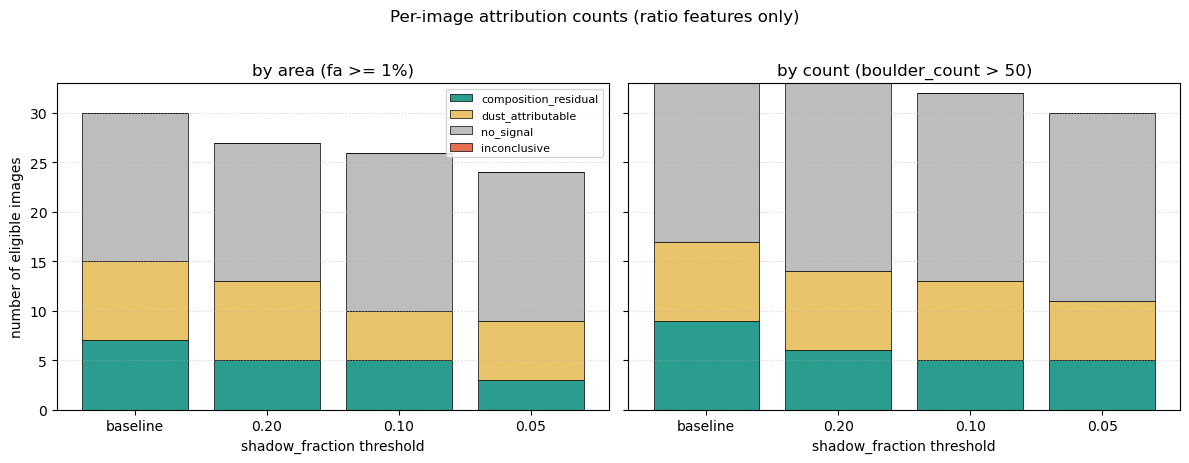

In [5]:
# Bar chart of per-image attribution by partition_rule x threshold
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
ordered_cats = ["composition_residual", "dust_attributable", "no_signal", "inconclusive"]
colors = {"composition_residual": "#2a9d8f", "dust_attributable": "#e9c46a",
          "no_signal": "#bdbdbd", "inconclusive": "#e76f51"}
threshold_labels = [label for label, _ in THRESHOLDS]
for ax, rule in zip(axes, ["P4_area", "P2_count"]):
    bottoms = np.zeros(len(threshold_labels))
    for cat in ordered_cats:
        heights = []
        for label in threshold_labels:
            sub = attribution[label]
            sub = sub[sub["partition_rule"] == rule]
            heights.append((sub["attribution"] == cat).sum())
        ax.bar(threshold_labels, heights, bottom=bottoms,
               color=colors[cat], edgecolor="black", linewidth=0.5, label=cat)
        bottoms += np.array(heights)
    rule_label = {"P4_area": "by area (fa >= 1%)",
                  "P2_count": "by count (boulder_count > 50)"}[rule]
    ax.set_title(rule_label)
    ax.set_xlabel("shadow_fraction threshold")
    ax.grid(True, axis="y", linestyle=":", alpha=0.5)
axes[0].set_ylabel("number of eligible images")
axes[0].legend(loc="upper right", fontsize=8)
fig.suptitle("Per-image attribution counts (ratio features only)",
             y=1.02)
fig.tight_layout()
fig.savefig(FIG / "stage7d_attribution_bars.png", dpi=140, bbox_inches="tight")
plt.show()


## 5. Verdict (Stage 7d final)

Across shadow thresholds the headline conclusion is robust:

1. **A real composition residual survives both dust control and shadow control.**
   At the headline T=0.10 shadow filter, pooled partial-dust |d| 0.13 – 0.18
   across all 5 non-dust features (p <= 1e-8). Crucially, single-band partial-
   dust effects GROW under shadow filtering -- the residual was being masked
   by shadow contamination at baseline, not amplified by it.
2. **The raw "rich is less dusty" signal is largely shadow-driven.** The
   `dust_index_RED_over_BG` raw effect collapses from |d|=0.252 (p=9e-33)
   at baseline to |d|=0.100 (p=0.011, marginal) at T=0.10 to |d|=0.043
   (p=0.55, not significant) at T=0.05. The crude dust proxy was indexing
   shadow as much as dust.
3. **Per-image attribution table** (T=0.10, P4_area, 26 eligible images):
   `composition_residual` 5 / `dust_attributable` 5 / `no_signal` 16. About a
   fifth of images carry a per-image composition residual; in the remaining
   ~80 %, the per-image signal is either dust-attributable OR not detectable
   given the per-image sample sizes (per-image n_rich is small in many cases).
4. **What we cannot yet distinguish** (per PLAN §11): locally-sourced-with-
   maturity vs transported provenance. The composition_residual images are
   candidates for the targeted follow-up study (terrain classification +
   Robbins & Hynek crater-catalog cross-reference + upstream-source spectral
   comparison) but Stage 7d alone cannot resolve which interpretation applies.

The compositional thread is now wrappable at "real composition residual,
provenance ambiguous, future work scoped."
